# Module 6 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

In [874]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy

**For this assignment only**

If you want to use NetworkX with your assignment, you can do:

```
conda install networkx
```
or

```
pip install networkx
```

Additionally, this assignment uses a recursive algorithm. You should use `deecopy` at the appropriate places to avoid entanglement issues.

1. Follow the pseudocode in the book exactly.
2. Learn about the [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem).


These links are to help me navigate your notebook:

1. [Four Color Connecticut](#four_ct)
2. [Three Color Connecticut](#three_ct)
3. [Four Color Europe](#four_eu)
4. [Three Color Europe](#three_eu)


## CSP: Map Coloring

In this programming assignment, you will be using your new understanding of **Constraint Satisfaction Problems** to color maps. As we know from the [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem) any division of a plane into contiguous regions can be colored such that no two adjacent regions are the same color by using at most four colors.

From the book, we know that we can translate this problem into a CSP where the map is represented as a [planar graph](http://en.wikipedia.org/wiki/Planar_graph) and the goal is to color all the nodes such that no adjacent nodes are colored the same color.

As with most AI problems, this requires us to figure out how best to represent the problem--and the solution--given the high and low level data structures and types at our disposal. For this problem, we'll settle on a Dict which contains at least two keys: "nodes" which is an *ordered* List of Strings that represents each node or vertex in the planar graph and "edges" which contains a List of Tuples that represent edges between nodes. The Tuples are of ints that represent the index of the node in the "nodes" list.

Using this system, and adding a "coordinates" key with abstract drawing coordinates of each node for NetworkX, we can represent the counties of Connecticut like so:

In [875]:
connecticut = {
    'coordinates': [(46, 52), (217, 146), (65, 142), (147, 85), (162, 140),
                 (104, 77), (197, 94), (123, 142)],
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['Fairfield', 'Windham', 'Litchfield', 'Middlesex', 'Tolland',
           'New Haven', 'New London', 'Hartford']}
print(connecticut)

{'coordinates': [(46, 52), (217, 146), (65, 142), (147, 85), (162, 140), (104, 77), (197, 94), (123, 142)], 'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4), (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)], 'nodes': ['Fairfield', 'Windham', 'Litchfield', 'Middlesex', 'Tolland', 'New Haven', 'New London', 'Hartford']}


The coordinates permit us to use NetworkX to draw the graph. We'll add a helper function for this, `draw_map`, which takes our planar_map, a figure size in abstract units, and a List of color assignments in the same order as the nodes in the planar_map.  The underlying drawings are made by matplotlib using NetworkX on top of it. Incidentally, the positions just make the map "work out" on NetworkX/matplotlib.

The size parameter is actually inches wide by inches tall (8, 10) is an 8x10 sheet of paper. Why doesn't a chart cover up the whole screen then? It's adjusted by dpi. On high resolution monitors, 300 dpi with 8x10 inches might only take up a fraction of that space. Use whatever you want to make the output look good. It doesn't matter for anything else but that.

A default value for `color_assignments` is provided, `None`, that simply colors all the nodes red. Otherwise, `color_assignments` must be a `List of Tuples` where each `Tuple` is a node name and assigned color. The order of `color_assignments` must be the same as the order of `"nodes"` in the `planar_map`.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>Do not use NetworkX nodes as the data structure for your assignment.
    We are only using it to color the maps.
    Use basic Python data structures as specified in the general programming requirements.</p>
</div>


In [876]:
def draw_map(name, planar_map, size, color_assignments=None):
    def as_dictionary(a_list):
        dct = {}
        for i, e in enumerate(a_list):
            dct[i] = e
        return dct
    
    G = nx.Graph()
    
    labels = as_dictionary(planar_map["nodes"])
    pos = as_dictionary(planar_map["coordinates"])
    
    # create a List of Nodes as indices to match the "edges" entry.
    nodes = [n for n in range(0, len(planar_map["nodes"]))]

    if color_assignments:
        colors = [c for n, c in color_assignments]
    else:
        colors = ['red' for c in range(0,len(planar_map[ "nodes"]))]

    G.add_nodes_from(nodes)
    G.add_edges_from(planar_map[ "edges"])

    plt.figure(figsize=size, dpi=100)
    plt.title(name)
    nx.draw(G, node_color = colors, with_labels = True, labels = labels, pos = pos)
    
#    plt.savefig(name + ".png")

Using this function, we can draw `connecticut`:

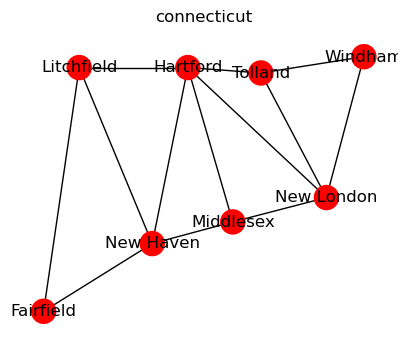

In [877]:
draw_map("connecticut", connecticut, (5,4), [(n, "red") for n in connecticut["nodes"]])

This coloring obviously has some problems! You're going to write a program to fix it.

So what we (and by "we", I mean "you") would like to do is write a program that can figure out how to color a planar map...ie, `connecticut` *and* `europe`, you will do it by implementing a function that uses the algorithms that were discussed in this module.

## Which CSP Algorithms?

You will need to implement **backtracking** and **forward checking**. Look at the pseudocode for `backtracking_search` on p. 192 of AIAMA 4th Edition.

You *must* implement **Degree Heuristic** (to pick variables) and **Least Constraining Value** (to pick values).
You *may* implement **Minimum Remaining Values** as a tie breaker, if you like.
Otherwise, break ties in ascending order (least to most).
(Which functions in the pseudocode represent the heuristics?).

You should get the backtracking and forward checking implemented first. 
Then add the heuristics. 
You must use the pseudocode in the book and then stub out the functions that implement the "pick a variable" heuristic and the "pick a value" heuristic. 
When you get it working, fill in the appropriate heuristic mentioned above.

Please change the "?" below into "yes" or "no" indicating which elements you were able to implement:

```
Required:
    backtracking: Yes
    forward checking: Yes
    degree heuristic: Yes
    least contraining value: Yes
Optional:    
    minimum remaining values: No
```  

Your function should take the following form:

```python
def color_map( planar_map, color_list, trace=False)
```

where `planar_map` has the format described above, colors is a List of Strings denoting the colors to use and `trace` operates as described in the next paragraph. It should return a List of Tuples where each Tuple is of the form `( Node Name, Color)` in the same order as the `node` entry in the planar_map. For example, if we had `["A", "B"]` as nodes and `["Yellow", "Green"]` as colors, your function might return `[("A", "Yellow"), ("B", "Green")]`. If a coloring cannot be found, return `None`.

Your function also will take an optional argument, `trace`, with a default value of `False`.

If `trace` is set to `True` your program will print out *traces* (or debugging) statements that show what it is currently doing (in terms of the algorithms you are supposed to implement):

1. The variable selected and why.
2. The values proposed in order.
3. backtracking detected by forward checking (empty domains).

Don't print out a lot of noise.

As usual, you should implement your function using helper functions, using one Markdown cell for documentation and one Codecell for implementation (one function and assertions).

-----

<a id="order_domain_values"></a>
## order_domain_values

`order_domain_values` orders the values (in this case color strings) for a given node, as part of solving a CSP problem. It uses the least constraining value heuristic, which orders the values by the number of unassigned neighbors with the same value. Ties are broken alphabetically. **Used by**: [backtrack](#backtrack)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str] "domains": dict[str, list[str]]}.
* **var** str: the node in the CSP to consider.
* **assignment** list[tuple[str, str]]: the list of assignments made so far in the CSP.

**returns** list[str]: the order of the colors to evaluate for a given node in the CSP.

In [878]:
def order_domain_values(csp: dict, var: str, assignment: list[tuple[str,str]]) -> list[str]:
    assigned_nodes = [node for (node, _) in assignment]
    node_idx = csp["nodes"].index(var)
    edges_with_idx = [edge for edge in csp["edges"] if node_idx in edge]
    neighbors_with_color = {}
    for color in csp["domains"][var]:
        neighbors_with_color[color] = 0
        for edge in edges_with_idx:
            neighbor_idx = edge[1] if node_idx == edge[0] else edge[0] 
            neighbor = csp["nodes"][neighbor_idx]
            if neighbor in assigned_nodes:
                continue
            if color in csp["domains"][neighbor]:
                neighbors_with_color[color] += 1
    sorted_neighbors_with_color = sorted(neighbors_with_color.items(), key=lambda kv: (kv[1], kv[0]))
    color_order = [color for color, _ in sorted_neighbors_with_color]
    return color_order


In [879]:
csp = {"edges": [(0,1)], "nodes": ["a", "b"], "domains": {"a": ["c1"], "b": ["c1"]}}
var = "a"
assignment = []
assert order_domain_values(csp, var, assignment) == ["c1"]
csp = {"edges": [(0,1), (2,1)], "nodes": ["a","b","c"], "domains": {"a": ["c1","c2"], "b": ["c1","c2"],"c": ["c1","c2"]}}
assert order_domain_values(csp, var, assignment) == ["c1","c2"]
csp = {"edges": [(0,1), (0,2)], "nodes": ["a","b","c"], "domains": {"a": ["c1","c2"], "b": ["c1","c2"],"c": ["c1","c2"]}}
assignment = [("b","c1")]
assert order_domain_values(csp, var, assignment) == ["c1","c2"]
csp = {"edges": [(0,1), (0,2)], "nodes": ["a","b","c"], "domains": {"a": ["c1","c2"], "b": ["c1"],"c": ["c1","c2"]}}
assignment = []
assert order_domain_values(csp, var, assignment) == ["c2","c1"]


<a id="inference"></a>
## inference

`inference` performs forward checking as part of the CSP algorithm we're using. It finds the neighbors of the current node, looks at the proposed assignment, and prunes that assignment from the neighbor domains. It returns None if any of the propagated prunings result in an empty neighbor domain. **Used by**: [backtrack](#backtrack)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str] "domains": dict[str, list[str]]}.
* **var** str: the node in the CSP to consider.
* **assignment** list[tuple[str, str]]: the list of assignments made so far in the CSP.
* **trace** bool: a debugging flag for whether to print verbose outputs.

**returns** list[tuple[str,str]] | None: None if the inferences/prunings caused an empty domain, or the inferences performed so they can added back in later if needed during backtracking.

In [880]:
def inference(csp: dict, var: str, assignment: list[tuple[str,str]], trace: bool) -> list[tuple[str,str]] | None:
    inferences = []
    assignment_dict = dict(assignment)
    var_color = assignment_dict[var]
    node_idx = csp["nodes"].index(var)
    edges_with_idx = [edge for edge in csp["edges"] if node_idx in edge]
    for edge in edges_with_idx:
        neighbor_idx = edge[1] if node_idx == edge[0] else edge[0] 
        neighbor = csp["nodes"][neighbor_idx]
        if neighbor in assignment_dict:
            continue
        if var_color in csp["domains"][neighbor]:
            csp["domains"][neighbor].remove(var_color)
            inferences.append((neighbor, var_color))
            if not csp["domains"][neighbor]:
                if trace: print(f"empty domain for node {neighbor}, backtracking")
                return None
    if trace: print(f"tree prunings from inference function {inferences}")
    return inferences

In [881]:
csp = {"edges": [(0,1)], "nodes": ["a", "b"], "domains": {"a": ["c1", "c2"], "b": ["c1", "c2"]}}
assignment = [("a", "c1")]
var = "a"
assert inference(csp, var, assignment, trace=False) == [("b", "c1")]
assert csp["domains"]["b"] == ["c2"]
csp = {"edges": [(0,1)], "nodes": ["a", "b"], "domains": {"a": ["c1", "c2"], "b": ["c1", "c2"]}}
assignment = [("a", "c2")]
var = "a"
assert inference(csp, var, assignment, trace=False) == [("b", "c2")]
assert csp["domains"]["b"] == ["c1"]

<a id="select_unassigned_variable"></a>
## select_unassigned_variable

`select_unassigned_variable` uses the degree heuristic to select the next unassigned variable in solving a constraint satisfaction problem. It finds the unassigned variables, checks how many unassigned connections each of those variables has, and then selects the variable with the most connections. Any ties are broken by alphabetical order. **Used by**: [backtrack](#backtrack)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str] "domains": dict[str, list[str]]}.
* **assignment** list[tuple[str, str]]: the list of assignment made so far in the CSP.
* **trace** bool: a debugging flag for whether to print verbose outputs.

**returns** str: the next variable to be assigned in the CSP.

In [882]:
def select_unassigned_variable(csp: dict, assignment: list[tuple[str, str]], trace: bool) -> str:
    assigned_nodes = [var for (var, _) in assignment]
    unassigned_nodes = [node for node in csp["nodes"] if node not in assigned_nodes]
    num_neighbors = {}
    for node in unassigned_nodes:
        num_neighbors[node] = 0
        node_idx = csp["nodes"].index(node)
        edges_with_idx = [edge for edge in csp["edges"] if node_idx in edge]
        for edge in edges_with_idx:
            edge_idx = edge[1] if node_idx == edge[0] else edge[0]
            if csp["nodes"][edge_idx] not in assigned_nodes:
                num_neighbors[node] += 1
    sorted_neighbors = dict(sorted(num_neighbors.items(), key=lambda kv: (-kv[1], kv[0])))
    selected = next(iter(sorted_neighbors.keys()))
    if trace:
        print(f"selecting variable, number of unassigned neighbors per node {sorted_neighbors}")
        print(f"selected {selected}")
    return selected


In [883]:
# test easy case, should choose a
csp = {"edges": [(0,1), (0,2), (0,3)], "nodes": ["a", "b", "c", "d"]}
assignment = []
assert select_unassigned_variable(csp, assignment, trace=False) == "a"
# test some already assigned, b should be chosen since a already assigned
assignment = [("a", "color")]
assert select_unassigned_variable(csp, assignment, trace=False) == "b"
# test alphabetical sorting for tie-breakers, a should be chosen
csp = {"edges": [(0,1)], "nodes": ["b", "a"]}
assignment = []
assert select_unassigned_variable(csp, assignment, trace=False) == "a"
# test a more complex network, b has most connections
csp = {"edges": [(0,1), (0,2), (1,2), (1,3)], "nodes": ["c", "b", "a", "d"]}
assignment = []
assert select_unassigned_variable(csp, assignment, trace=False) == "b"
# test complex network with existing assignment
csp = {"edges": [(0,1), (0,2), (1,2), (1,3)], "nodes": ["a", "b", "c", "d"]}
assignment = [("a", "color")]
assert select_unassigned_variable(csp, assignment, trace=False) == "b"

<a id="is_consistent"></a>
## is_consistent

`is_consistent` checks that a given assignment for a variable in a CSP is consistent with its assigned neighbors. **Used by**: [backtrack](#backtrack)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str] "domains": dict[str, list[str]]}.
* **var** str: the proposed color for assignment.
* **assignment** list[tuple[str, str]]: the list of assignments made so far in the CSP.

**returns** bool: true if the proposed variable assignment does not violate any constraints with neightbors, otherwise returns false.

In [884]:
def is_consistent(csp: dict, var: str, val: str, assignment: list[tuple[str,str]]) -> bool:
    node_idx = csp["nodes"].index(var)
    edges_with_idx = [edge for edge in csp["edges"] if node_idx in edge]
    for edge in edges_with_idx:
        neighbor_idx = edge[1] if node_idx == edge[0] else edge[0] 
        neighbor = csp["nodes"][neighbor_idx]
        neighbor_assignment = next((t for t in assignment if t[0] == neighbor), None)
        if not neighbor_assignment:
            continue
        neighbor_color = neighbor_assignment[1]
        if val == neighbor_color:
            return False
    return True 

In [885]:
csp = {"edges": [(0,1)], "nodes": ["a", "b"]}
var = "a"; val = "c1" ; assignment = []
assert is_consistent(csp, var, val, assignment) == True
var = "a"; val = "c1" ; assignment = [("b", "c2")]
assert is_consistent(csp, var, val, assignment) == True
var = "a"; val = "c1" ; assignment = [("b", "c1")]
assert is_consistent(csp, var, val, assignment) == False

<a id="backtrack"></a>
## backtrack

`backtrack` performs backtracking in the DFS as part of solving a CSP. It performs a recursive DFS search, assigning colors to nodes, and backtracks if any assignment violates constraints. It prunes the search tree prior to recursion, as well as restores the prunings when an assignment doesn't work. **Uses**: [select_unassigned_variables](#select_unassigned_variable), [order_domain_values](#order_domain_values), [inference](#inference), [backtrack](#backtrack) **Used by**: [backtracking_search](#backtracking_search)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str] "domains": dict[str, list[str]]}.
* **assignment** list[tuple[str, str]]: the list of assignments made so far in the CSP.
* **trace** bool: a debugging flag for whether to print verbose outputs.

**returns** list[tuple[str, str]] | None: returns the pruned CSP search tree, or None if an assignment results in failure.

In [886]:
def backtrack(csp: dict, assignment: list[tuple[str, str]], trace: bool) -> list[tuple[str, str]] | None:
    if trace: print(f"domains: {csp['domains']}")
    if len(assignment) == len(csp["nodes"]):
        return assignment
    var = select_unassigned_variable(csp, assignment, trace)
    values = order_domain_values(csp, var, assignment)
    for val in values:
        if trace: print(f"evaluating variable {var} with value {val} from ordered values {values}")
        if is_consistent(csp, var, val, assignment):
            pruned_csp = deepcopy(csp)
            assignment.append((var,val))
            if trace: print("assignment ", assignment)
            pruned_csp["domains"][var] = [val]
            inferences = inference(pruned_csp, var, assignment, trace)
            if inferences is not None:
                result = backtrack(pruned_csp, assignment, trace)
                if result is not None: 
                    return result
            assignment.remove((var, val))
    return None   

In [887]:
csp = {"edges": [(0,1)], "nodes": ["a", "b"], "domains": {"a": ["c1", "c2"], "b": ["c1", "c2"]}}
assignment = []
assert backtrack(csp, assignment, trace=False) == [("a", "c1"), ("b", "c2")]
csp = {"edges": [(0,1)], "nodes": ["a", "b"], "domains": {"a": ["c1"], "b": ["c1"]}}
assignment = []
assert backtrack(csp, assignment, trace=False) == None
csp = {"edges": [(0,1), (0,2)], "nodes": ["a", "b", "c"], "domains": {"a": ["c1", "c2", "c3"], "b": ["c1", "c2", "c3"], "c": ["c1", "c2", "c3"] }}
assignment = []
assert backtrack(csp, assignment, trace=False) == [("a", "c1"), ("b", "c2"), ("c", "c2")]

<a id="augment_csp"></a>
## augment_csp

`augment_csp` augments the original CSP data structure with the domain for each node (i.e. the color list). This allows us to implement forward checking in solving the problem. **Used by**: [backtracking_search](#backtracking_search)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str]}.
* **color_list** list[str]: the list of colors to be used in coloring the map, and also for the domain for each variable.

**returns** dict: the augmented CSP, with the domains for each variable added. It now has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str] "domains": dict[str, list[str]]}

In [888]:
def augment_csp(csp: dict, color_list: list[str]) ->  dict:
    augmented_csp = deepcopy(csp)
    augmented_csp["domains"] = {n: list(color_list) for n in augmented_csp["nodes"]}
    return augmented_csp

In [889]:
csp = {"edges": [], "nodes": ["a"]}
color_list = []
assert augment_csp(csp, color_list) == {"edges": [], "nodes": ["a"], "domains": {"a": []}}
color_list = ["color"]
assert augment_csp(csp, color_list) == {"edges": [], "nodes": ["a"], "domains": {"a": ["color"]}}
csp = {"edges": [], "nodes": ["a", "b"]}
color_list = ["color1", "color2"]
assert augment_csp(csp, color_list) == {"edges": [], "nodes": ["a", "b"], "domains": {"a": ["color1", "color2"], "b": ["color1", "color2"]}}

<a id="backtracking_search"></a>
## backtracking_search

`backtracking_search` is a wrapper around the CSP backtracking algorithm that performs some additional processing. It augments the original CSP problem given from color_map, by adding the domain for each variable. It also reorders the assignments to match the variable order in the original CSP before passing the resulting assignment back to color_map. **Uses**: [backtrack](#backtrack) **Used by**: [color_map](#color_map)

* **csp** dict: the constraint satisfaction problem to be solved. It has the form {"coordinates": list[tuple], "edges": list[tuple], "nodes": list[str]}.
* **color_list** list[str]: the list of allowed colors from which to create the domain for each variable.
* **trace** bool: a debugging flag for whether to print verbose outputs.

**returns** list[tuple[str, str]] | None: returns the assignments in the order given in the original CSP from color_map, or None if the algorithm could not find assignments that satisfy the constraints.

In [890]:
def backtracking_search(csp: dict[str, list[tuple] | list[str]], color_list: list[str], trace: bool) -> list[tuple[str, str]] | None:
    augmented_csp = augment_csp(csp, color_list)
    assignment = backtrack(augmented_csp, [], trace)
    if assignment:
        tmp = dict(assignment)
        assignment = [(node, tmp[node]) for node in csp["nodes"]]
    return assignment

In [891]:
csp = {"edges": [(0,1)], "nodes": ["a", "b"]}
color_list = ["c1", "c2"]
assert backtracking_search(csp, color_list, trace=False) == [("a", "c1"), ("b", "c2")]
csp = {"edges": [(0,1)], "nodes": ["a", "b"]}
color_list = ["c1"]
assert backtracking_search(csp, color_list, trace=False) == None
csp = {"edges": [(0,1)], "nodes": ["a", "b"]}
color_list = ["c1", "c2", "c3"]
assert [("a", "c1"), ("b", "c2"), ("c", "c2")]

<a id="color_map"></a>
## color_map

`color_map` colors an arbitrary map modeled as a graph, using the Russel and Norvig backtracking_search algorithm, implemented with backtracking, forward checking, degree heuristic for variable selection, and least contraining value for value selection. **Uses**: [backtracking_search](#backtracking_search)

* **planar_map** the graph dictionary that is solved using the CSP techniques.
* **color_list** list[str]: the list of allowed colors from which to create the domain for each variable.
* **trace** bool: a debugging flag for whether to print verbose outputs.

**returns** list[tuple[str, str]] | None: the assignments for each graph node, or None if the constraints could not be met.

In [892]:
def color_map(planar_map: dict, color_list: list[str], trace=False) -> list[tuple[str, str]] | None:
    return backtracking_search(planar_map, color_list, trace)

Currently, it just colors everything red. When you are done, if it cannot find a coloring, it should return `None`.

## Problem 1. Color Connecticut Using Your Solution

In [893]:
connecticut_colors = color_map(connecticut, ["red", "blue", "green", "yellow"], trace=True)

domains: {'Fairfield': ['red', 'blue', 'green', 'yellow'], 'Windham': ['red', 'blue', 'green', 'yellow'], 'Litchfield': ['red', 'blue', 'green', 'yellow'], 'Middlesex': ['red', 'blue', 'green', 'yellow'], 'Tolland': ['red', 'blue', 'green', 'yellow'], 'New Haven': ['red', 'blue', 'green', 'yellow'], 'New London': ['red', 'blue', 'green', 'yellow'], 'Hartford': ['red', 'blue', 'green', 'yellow']}
selecting variable, number of unassigned neighbors per node {'Hartford': 5, 'New Haven': 4, 'New London': 4, 'Litchfield': 3, 'Middlesex': 3, 'Tolland': 3, 'Fairfield': 2, 'Windham': 2}
selected Hartford
evaluating variable Hartford with value blue from ordered values ['blue', 'green', 'red', 'yellow']
assignment  [('Hartford', 'blue')]
tree prunings from inference function [('Litchfield', 'blue'), ('New Haven', 'blue'), ('Middlesex', 'blue'), ('Tolland', 'blue'), ('New London', 'blue')]
domains: {'Fairfield': ['red', 'blue', 'green', 'yellow'], 'Windham': ['red', 'blue', 'green', 'yellow'], 'L

Using the "edges" list from the connecticut map, we can test to see if each pair of adjacent nodes is indeed colored differently:

<a id="four_ct"></a>
#### Test Cases

In [894]:
edges = connecticut["edges"]
nodes = connecticut[ "nodes"]
colors = connecticut_colors
COLOR = 1

for start, end in edges:
    try:
        assert colors[start][COLOR] != colors[end][COLOR]
    except AssertionError:
        print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

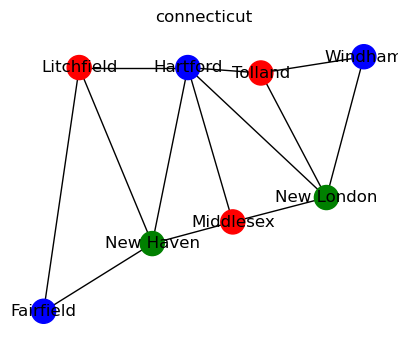

In [895]:
draw_map("connecticut", connecticut, (5,4), connecticut_colors)

<a id="three_ct"></a>
## Does the Four Color Theorem apply here? Yes, but it turns out that we can satisfy the constraints for this map with three colors.

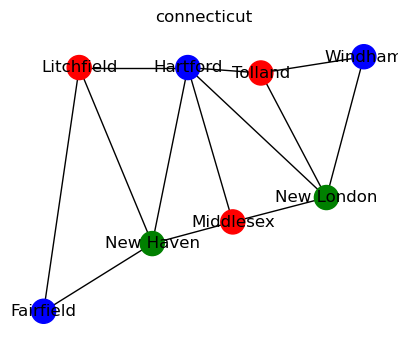

In [896]:
connecticut_colors = color_map( connecticut, ["red", "blue", "green"], trace=False)
if connecticut_colors:
    draw_map("connecticut", connecticut, (5,4), connecticut_colors)

## Problem 2. Color Europe Using Your solution

In [897]:
europe = {
    'coordinates': [(47, 28), (108, 14), (18, 147), (48, 83), (98, 59), (148, 57),
                 (160, 13), (63, 34), (84, 80), (82, 69), (136, 95), (194, 32),
                 (94, 97), (143, 149), (140, 111), (110, 67), (127, 40),
                 (118, 47), (111, 54), (189, 39), (202, 33), (82, 74),
                 (110, 162), (137, 102), (93, 55), (125, 32), (128, 37),
                 (122, 42), (116, 53), (124, 65), (146, 87), (138, 54),
                 (137, 41), (64, 90), (130, 22), (168, 29), (78, 55),
                 (116, 144), (122, 57), (158, 65), (122, 78), (112, 60),
                 (127, 48), (191, 118), (100, 78), (102, 35)],
 'edges': [(2, 3), (2, 33), (3, 33), (33, 36), (33, 21), (33, 8), (33, 22),
           (0, 7), (7, 36), (7, 45), (36, 21), (36, 9), (36, 44), (36, 24),
           (36, 45), (21, 8), (21, 9), (21, 44), (8, 44), (9, 44), (44, 12),
           (44, 37), (44, 40), (44, 15), (44, 41), (44, 24), (12, 22), (12, 37),
           (12, 40), (22, 37), (22, 13), (22, 43), (37, 13), (37, 14), (37, 23),
           (37, 40), (13, 14), (13, 43), (14, 23), (14, 43), (23, 10), (23, 30),
           (23, 43), (10, 40), (10, 30), (40, 15), (40, 29), (40, 30), (40, 39),
           (15, 41), (15, 29), (41, 4), (41, 24), (41, 45), (41, 18), (41, 38),
           (41, 29), (4, 24), (24, 45), (45, 1), (45, 34), (45, 25), (45, 27),
           (45, 17), (45, 28), (45, 18), (34, 25), (34, 26), (34, 32), (34, 6),
           (34, 35), (25, 26), (25, 16), (25, 27), (26, 16), (26, 42), (26, 32),
           (16, 27), (16, 42), (27, 17), (27, 42), (17, 42), (17, 28), (42, 28),
           (42, 38), (42, 31), (42, 32), (28, 18), (28, 38), (18, 38), (38, 29),
           (38, 39), (38, 31), (29, 39), (30, 39), (30, 43), (39, 5), (39, 31),
           (39, 43), (5, 31), (31, 32), (32, 35), (6, 35), (35, 19), (35, 11),
           (35, 20), (19, 11), (19, 20), (19, 43), (11, 20), (20, 43)],
 'nodes': ['Portugal', 'Malta', 'Iceland', 'Ireland', 'Liechtenstein',
           'Moldova', 'Cyprus', 'Spain', 'Netherlands', 'Luxembourg',
           'Lithuania', 'Armenia', 'Denmark', 'Finland', 'Estonia',
           'Czech Republic', 'Kosovo', 'Bosnia Herzegovina', 'Slovenia',
           'Georgia', 'Azerbaijan', 'Belgium', 'Norway', 'Latvia',
           'Switzerland', 'Albania', 'Macedonia', 'Montenegro', 'Croatia',
           'Slovakia', 'Belarus', 'Romania', 'Bulgaria', 'United Kingdom',
           'Greece', 'Turkey', 'France', 'Sweden', 'Hungary', 'Ukraine',
           'Poland', 'Austria', 'Serbia', 'Russia', 'Germany', 'Italy']}
print(europe)

{'coordinates': [(47, 28), (108, 14), (18, 147), (48, 83), (98, 59), (148, 57), (160, 13), (63, 34), (84, 80), (82, 69), (136, 95), (194, 32), (94, 97), (143, 149), (140, 111), (110, 67), (127, 40), (118, 47), (111, 54), (189, 39), (202, 33), (82, 74), (110, 162), (137, 102), (93, 55), (125, 32), (128, 37), (122, 42), (116, 53), (124, 65), (146, 87), (138, 54), (137, 41), (64, 90), (130, 22), (168, 29), (78, 55), (116, 144), (122, 57), (158, 65), (122, 78), (112, 60), (127, 48), (191, 118), (100, 78), (102, 35)], 'edges': [(2, 3), (2, 33), (3, 33), (33, 36), (33, 21), (33, 8), (33, 22), (0, 7), (7, 36), (7, 45), (36, 21), (36, 9), (36, 44), (36, 24), (36, 45), (21, 8), (21, 9), (21, 44), (8, 44), (9, 44), (44, 12), (44, 37), (44, 40), (44, 15), (44, 41), (44, 24), (12, 22), (12, 37), (12, 40), (22, 37), (22, 13), (22, 43), (37, 13), (37, 14), (37, 23), (37, 40), (13, 14), (13, 43), (14, 23), (14, 43), (23, 10), (23, 30), (23, 43), (10, 40), (10, 30), (40, 15), (40, 29), (40, 30), (40, 

In [898]:
europe_colors = color_map(europe, ["red", "blue", "green", "yellow"], trace=True)

domains: {'Portugal': ['red', 'blue', 'green', 'yellow'], 'Malta': ['red', 'blue', 'green', 'yellow'], 'Iceland': ['red', 'blue', 'green', 'yellow'], 'Ireland': ['red', 'blue', 'green', 'yellow'], 'Liechtenstein': ['red', 'blue', 'green', 'yellow'], 'Moldova': ['red', 'blue', 'green', 'yellow'], 'Cyprus': ['red', 'blue', 'green', 'yellow'], 'Spain': ['red', 'blue', 'green', 'yellow'], 'Netherlands': ['red', 'blue', 'green', 'yellow'], 'Luxembourg': ['red', 'blue', 'green', 'yellow'], 'Lithuania': ['red', 'blue', 'green', 'yellow'], 'Armenia': ['red', 'blue', 'green', 'yellow'], 'Denmark': ['red', 'blue', 'green', 'yellow'], 'Finland': ['red', 'blue', 'green', 'yellow'], 'Estonia': ['red', 'blue', 'green', 'yellow'], 'Czech Republic': ['red', 'blue', 'green', 'yellow'], 'Kosovo': ['red', 'blue', 'green', 'yellow'], 'Bosnia Herzegovina': ['red', 'blue', 'green', 'yellow'], 'Slovenia': ['red', 'blue', 'green', 'yellow'], 'Georgia': ['red', 'blue', 'green', 'yellow'], 'Azerbaijan': ['red',

Here we're testing to see if the adjacent nodes are colored differently:

<a id="four_eu"></a>
#### Test Cases

In [899]:
edges = europe["edges"]
nodes = europe[ "nodes"]
colors = europe_colors
COLOR = 1

for start, end in edges:
    try:
        assert colors[start][COLOR] != colors[end][COLOR]
    except AssertionError:
        print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

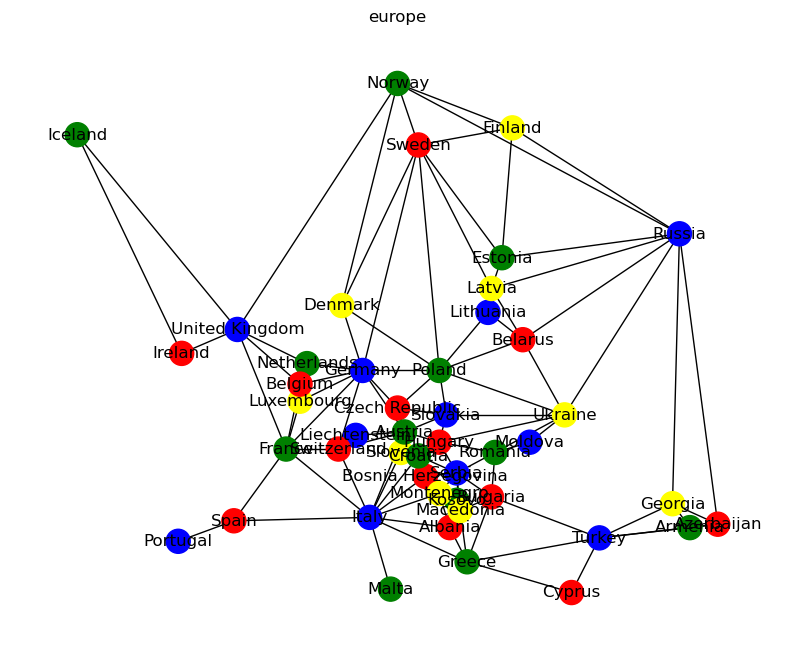

In [900]:
draw_map("europe", europe, (10,8), europe_colors)

<a id="three_eu"></a>
## Does the Four Color Theorem apply here? Yes, but it turns out that we can satisfy the constraints for this map with three colors.

In [901]:
europe_colors = color_map(europe, ["red", "blue", "green"], trace=False)
if europe_colors:
     draw_map("europe", europe, (10,8), europe_colors)

## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.